# Proyecto Final

Para mi proyecto final el curso nos pedía realizar un modelo que predecia la lluvia en Australia, sin embargo voy a intentar realizar el mismo modelo pero sobre Argentina, para esto voy  estar utilizando un Dataset de [Kaggle](https://www.kaggle.com) cortesía de [Minahil Fatima](https://www.kaggle.com/minahilfatima12328).<br> En cuanto a los aspectos técnicos, voy a estar utilizando 2 modelos: Random Forest y KNN.

### SETUP
Descargamos e importamos librerias y dataset

In [115]:
!pip install -q kagglehub[pandas-datasets]
!pip install -q numpy
!pip install -q matplotlib
!pip install -q pandas
!pip install -q scikit-learn
!pip install -q seaborn

In [116]:
import kagglehub
from kagglehub import KaggleDatasetAdapter
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.decomposition import PCA
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay


file_path = "Argentina_weather_data.csv"

df = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "minahilfatima12328/argentina-atmospheric-data",
  file_path,
)

/tmp/ipykernel_177348/752403549.py:21: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


## Estudio del Dataset

Veamos un poco el formato que tiene nuestro dataset y analicemos cuales features son las más adecuadas para la predicción a primera vista.

In [117]:
df.dtypes

Country               object
Date                  object
Temp_Max             float64
Temp_Min             float64
Temp_Mean            float64
Precipitation_Sum    float64
Windspeed_Max        float64
Windgusts_Max        float64
Sunshine_Duration    float64
dtype: object

Obtengamos un pequeño sample

In [118]:
df.head()

,Country,Date,Temp_Max,Temp_Min,Temp_Mean,Precipitation_Sum,Windspeed_Max,Windgusts_Max,Sunshine_Duration
0,Argentina,01-01-2000,33.9,20.7,27.5,0.0,17.9,32.8,49047.75
1,Argentina,02-01-2000,32.9,22.2,27.3,0.6,23.1,43.6,48969.22
2,Argentina,03-01-2000,32.1,21.0,26.9,0.0,20.6,40.7,48921.57
3,Argentina,04-01-2000,32.2,20.9,26.7,0.0,25.1,47.2,48091.20
4,Argentina,05-01-2000,30.5,21.0,25.7,0.0,23.7,45.4,48922.09


Algunas observaciónes importantes son que nuestra temperatura está medida en grados Celsios, la precipitación en mililitros y la duración de la luz solar en segundos.

## Estudio y Preprocesamiento del Dataset

Podemos notar un pequeño problema en el dataset y es que no tenemos una variable binaria de si llovió ese dia o no, por suerte aplicando un poco de _feature engineering_ podemos resolverlo fácilmente. 

In [119]:
#Pongamos un threshold arbitrario (en este caso pongo 1mm de lluvia, que es lo que usa el dataset de Australia)
threshold = 1

df['rained'] = df['Precipitation_Sum'].apply(lambda x: 'Yes' if x > threshold else 'No')

df['Date'] = pd.to_datetime(df['Date'], format="%d-%m-%Y")

Con esto resolvemos el problema de nuestra variable objetivo, otro arreglo que podemos hacer para obtener mejores resultados es prestarle atención a las fechas. Actualmente nuestra columna de fechas no aporta información ningúna para las predicciones, pero sabemos que la lluvia es fuertemente dependiente de las estaciones y eso es fácilmente deducible e incorporable al dataset gracias a las fechas. 

In [120]:
def date_to_season(date):
    month = date.month
    if (month == 12) or (month == 1) or (month == 2):
        return 'Summer'
    elif (month == 3) or (month == 4) or (month == 5):
        return 'Autumn'
    elif (month == 6) or (month == 7) or (month == 8):
        return 'Winter'
    elif (month == 9) or (month == 10) or (month == 11):
        return 'Spring'


df["season"] = df["Date"].apply(date_to_season)

Ahora podemos eliminar ciertos datos redundantes, como por ejemplo el país (dado que únicamente es sobre Argentina), la fecha y la precipitación acumulada, además de eliminar cualquier registro con campos vacíos.

In [121]:
df.dropna()
df = df.drop(columns=["Country","Date","Precipitation_Sum"])

Todavía nos quedan ~8700 registros, que es un buen número para nuestro modelo. <br>

Teniendo estos registros "purificados" podemos ver la distrbiución de valores de nuestra variable objetivo

<Axes: ylabel='count'>

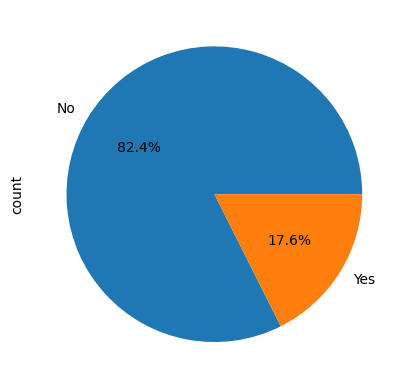

In [122]:
df["rained"].value_counts().plot(kind='pie',  autopct='%1.1f%%')

Podemos notar una gran diferencia en la distrbiución de nuestro target, esto nos podría llevar a un overfitting de casos negativos y underfitting de los positivos. Esto podemos evitarlo en la separación de entrenamiento/validación mediante el _stratify_.

### Procesamiento del Dataset

Ahora definamos features y target

In [123]:
X = df.drop(columns=["rained"])
Y = df["rained"]

Armemos el split entrenamiento/validación

In [124]:

X_test, X_train, Y_test, Y_train = train_test_split(X,Y, test_size=0.2, random_state=24, stratify=Y)


Y creemos los transformadores según el tipo de dato, escalando y codificando para cada caso.

In [125]:
#Separamos en features numéricos y categóricos
numeric_features = X_train.select_dtypes(include=['number']).columns.tolist()  
categorical_features = X_train.select_dtypes(include=['object', 'category']).columns.tolist()

# Normalizamos valores numéricos
numeric_transformer = Pipeline(steps=[('scaler', StandardScaler())])


categorical_transformer = Pipeline(steps=[('onehot', OneHotEncoder(handle_unknown='ignore'))])

## Pipeline con Random Forest
Armemos el pipeline, vamos a utilizar  un preprocesador (con los transformadores declarados anteriormente),  un estimador de tipo random forests y por último lo optimizamos mediante cross-validation de los hiperparametros.

Preprocesador:

In [126]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

Pipeline:

In [127]:
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(random_state=42))
])


Optimización:

In [128]:
param_grid = {
    'classifier__n_estimators': [50, 100],
    'classifier__max_depth': [None, 10, 20],
    'classifier__min_samples_split': [2, 5]
}

cv = StratifiedKFold(n_splits=5, shuffle=True)

grid_search = GridSearchCV(pipeline, param_grid, cv=cv, scoring='accuracy', verbose=2)  
grid_search.fit(X_train, Y_train)


Fitting 5 folds for each of 12 candidates, totalling 60 fits
[CV] END classifier__max_depth=None, classifier__min_samples_split=2, classifier__n_estimators=50; total time=   0.1s
[CV] END classifier__max_depth=None, classifier__min_samples_split=2, classifier__n_estimators=50; total time=   0.1s
[CV] END classifier__max_depth=None, classifier__min_samples_split=2, classifier__n_estimators=50; total time=   0.1s
[CV] END classifier__max_depth=None, classifier__min_samples_split=2, classifier__n_estimators=50; total time=   0.1s
[CV] END classifier__max_depth=None, classifier__min_samples_split=2, classifier__n_estimators=50; total time=   0.1s
[CV] END classifier__max_depth=None, classifier__min_samples_split=2, classifier__n_estimators=100; total time=   0.2s
[CV] END classifier__max_depth=None, classifier__min_samples_split=2, classifier__n_estimators=100; total time=   0.2s
[CV] END classifier__max_depth=None, classifier__min_samples_split=2, classifier__n_estimators=100; total time=

GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=None, shuffle=True),
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('num',
                                                                         Pipeline(steps=[('scaler',
                                                                                          StandardScaler())]),
                                                                         ['Temp_Max',
                                                                          'Temp_Min',
                                                                          'Temp_Mean',
                                                                          'Windspeed_Max',
                                                                          'Windgusts_Max',
                                                                          'Sunshine_Duration']),
                                                                        ('cat',
                                                                         Pipeline(steps=[('onehot',
                                                                                          OneHotEncoder(handle_unknown='ignore'))]),
                                                                         ['season'])])),
                                       ('classifier',
                                        RandomForestClassifier(random_state=42))]),
             param_grid={'classifier__max_depth': [None, 10, 20],
                         'classifier__min_samples_split': [2, 5],
                         'classifier__n_estimators': [50, 100]},
             scoring='accuracy', verbose=2)

## Análisis de Resultados

Hagamos las predicciones con el split de validación y veamos los resultados que nos arroja.<br> _Nota: Voy a guardar la relación de importancia de las features para algo que analizo más adelante_

In [129]:
y_pred = grid_search.predict(X_test)

feature_names = numeric_features + list(grid_search.best_estimator_['preprocessor']
                                        .named_transformers_['cat']
                                        .named_steps['onehot']
                                        .get_feature_names_out(categorical_features))

feature_importances = grid_search.best_estimator_['classifier'].feature_importances_



print("\nClassification Report:")
print(classification_report(Y_test, y_pred))



Classification Report:
              precision    recall  f1-score   support

          No       0.88      0.96      0.92      5779
         Yes       0.69      0.38      0.49      1233

    accuracy                           0.86      7012
   macro avg       0.79      0.67      0.70      7012
weighted avg       0.85      0.86      0.84      7012



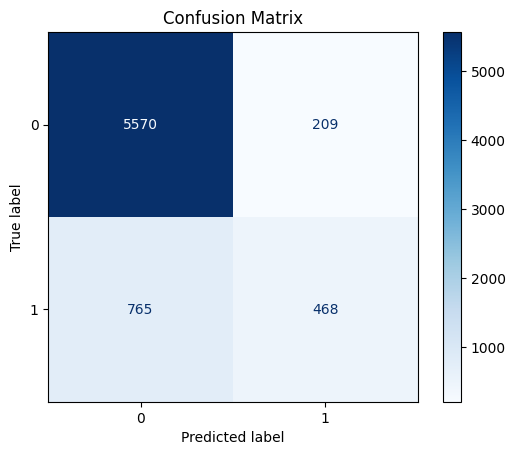

In [130]:
conf_matrix = confusion_matrix(Y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix)
disp.plot(cmap='Blues')
plt.title('Confusion Matrix')
plt.show()

Nuestro modelo no tiene un desempeño ideal, tiene una probabilidad del 40% de acertar los días de lluvia. Podríamos entonces intentar otro algoritmo para ver si mejora.

## Pipeline con KNN

Actualicemos nuestro pipeline para predecir mediante KNN, obviamente tenemos que además modificar la matriz de parametros-

In [131]:
pipeline.set_params(classifier=KNeighborsClassifier())

grid_search.estimator = pipeline

knn_param_grid = {
    'classifier__n_neighbors' : [3,5,7,9,15,20],
    'classifier__weights': ['uniform', 'distance'],
    'classifier__p' : [1, 2]
}

grid_search.param_grid = knn_param_grid

grid_search.fit(X_train, Y_train)

knn_y_pred = grid_search.predict(X_test)

Fitting 5 folds for each of 24 candidates, totalling 120 fits
[CV] END classifier__n_neighbors=3, classifier__p=1, classifier__weights=uniform; total time=   0.0s
[CV] END classifier__n_neighbors=3, classifier__p=1, classifier__weights=uniform; total time=   0.0s
[CV] END classifier__n_neighbors=3, classifier__p=1, classifier__weights=uniform; total time=   0.0s
[CV] END classifier__n_neighbors=3, classifier__p=1, classifier__weights=uniform; total time=   0.0s
[CV] END classifier__n_neighbors=3, classifier__p=1, classifier__weights=uniform; total time=   0.0s
[CV] END classifier__n_neighbors=3, classifier__p=1, classifier__weights=distance; total time=   0.0s
[CV] END classifier__n_neighbors=3, classifier__p=1, classifier__weights=distance; total time=   0.0s
[CV] END classifier__n_neighbors=3, classifier__p=1, classifier__weights=distance; total time=   0.0s
[CV] END classifier__n_neighbors=3, classifier__p=1, classifier__weights=distance; total time=   0.0s
[CV] END classifier__n_ne


Classification Report:
              precision    recall  f1-score   support

          No       0.88      0.96      0.92      5779
         Yes       0.69      0.37      0.48      1233

    accuracy                           0.86      7012
   macro avg       0.78      0.67      0.70      7012
weighted avg       0.84      0.86      0.84      7012



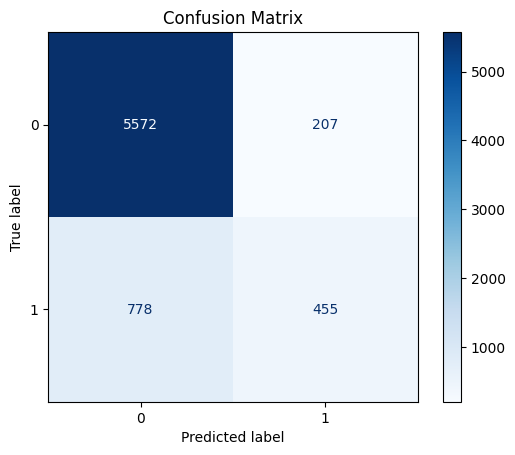

In [132]:
print("\nClassification Report:")
print(classification_report(Y_test, knn_y_pred))

conf_matrix = confusion_matrix(Y_test, knn_y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix)
disp.plot(cmap='Blues')
plt.title('Confusion Matrix')
plt.show()


Esta segunda iteración fue levemente peor que la primera, nos encontramos con el mismo problema y es que el modelo tiene una buena "precisión general" prediciendo dias sin lluvia constantemente. <br>

Sin embargo y teniendo en cuenta el estado del dataset (en particular la falta de features relacionadas con nuestro dataset) no se puede esperar una precisión mucho mas elevada.<br> Uno podría aplicar estos 2 modelos a un dataset más enriquecido con features que aporten a las predicciones y obtendría mejores resultados respecto a los falsos negativos (el punto débil de nuestro modelo actual). <br> En ese contexto es importante recordar que KNN necesita tener únicamente features con una relación sólida a la variable objetivo ya que cualquier otra cosa genera ruido en las predicciones, mientras que Random Forests se encarga automáticamente de asignar "prioridades" a las predicciones. De hecho, aprovechemos para ver las prioridades asignadas por nuestro modelo en este dataset.

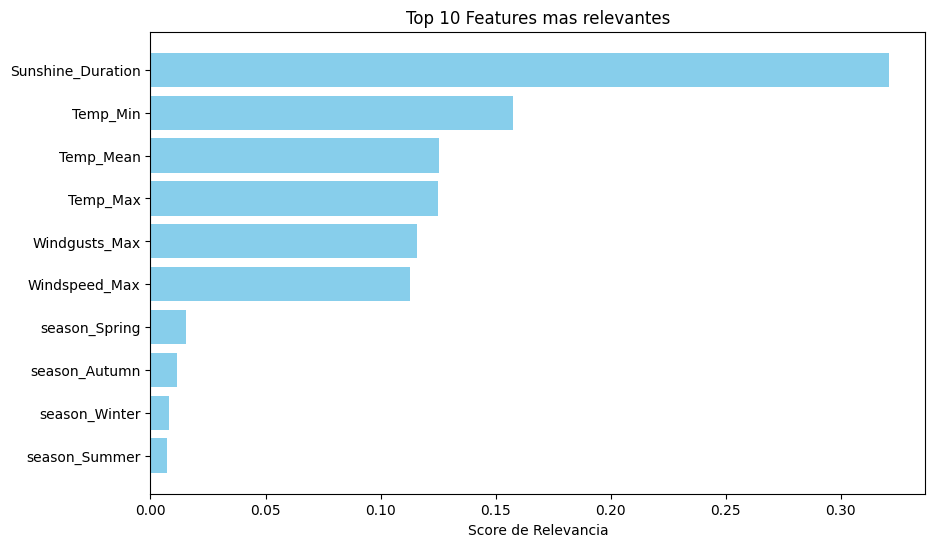

In [134]:
importance_df = pd.DataFrame({'Feature': feature_names,
                              'Importance': feature_importances
                             }).sort_values(by='Importance', ascending=False)

feature_number = len(feature_names)
top_features = importance_df.head(feature_number)

# Plotting
plt.figure(figsize=(10, 6))
plt.barh(top_features['Feature'], top_features['Importance'], color='skyblue')
plt.gca().invert_yaxis()  
plt.title(f'Top {feature_number} Features mas relevantes')
plt.xlabel('Score de Relevancia')
plt.show()

Esto esta bueno combinarlo con una iteración de KNN que descarte las features menos relevantes para evitar incrementar la precisión eliminando ruido.<br>
Igualmente creo que es interesante notar como las features a las que nuestro modelo de Random Forest les dió mas relevancia se ajustan con lo que uno naturalmente ve lógico (Días poco soleados y de baja temperatura en general llevan a precipitaciones). Esto es un fuerte indicador de que nuestro modelo en sí esta bien encaminado y probablemente solo requiere un mayor contexto para incrementar su precisión.